In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


In [82]:
df = pd.read_csv('/home/ipartzix/ML-dataset/Iris.csv')

In [83]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [84]:
df.shape

(150, 6)

In [85]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [86]:
df= df.drop(['Id'], axis=1)

In [87]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
146,6.3,2.5,5.0,1.9,Iris-virginica
14,5.8,4.0,1.2,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
38,4.4,3.0,1.3,0.2,Iris-setosa
95,5.7,3.0,4.2,1.2,Iris-versicolor


In [88]:
encoder = LabelEncoder()

In [89]:
df['Species']=encoder.fit_transform(df['Species'])

In [90]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,1
93,5.0,2.3,3.3,1.0,1
148,6.2,3.4,5.4,2.3,2
49,5.0,3.3,1.4,0.2,0
58,6.6,2.9,4.6,1.3,1


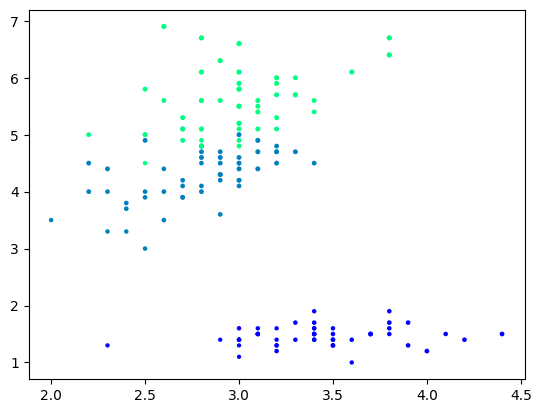

In [91]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],df['SepalLengthCm'],c=df['Species'],cmap='winter')

In [92]:
X = df.drop('Species', axis=1)
y = df['Species']

In [93]:
# # Step 1: Split into Train+Validation (90%) and Test (10%)
# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y, test_size=0.10, random_state=42
# )

# # Step 2: Split Train+Validation into final Train (80%) and Validation (10%)
# # Note: 0.1111 is roughly 1/9, which takes 10% of the original 90%
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val, test_size=0.1111, random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
print(X_train)
# print(X_val)
print(X_test)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
22             4.6           3.6            1.0           0.2
15             5.7           4.4            1.5           0.4
65             6.7           3.1            4.4           1.4
11             4.8           3.4            1.6           0.2
42             4.4           3.2            1.3           0.2
..             ...           ...            ...           ...
71             6.1           2.8            4.0           1.3
106            4.9           2.5            4.5           1.7
14             5.8           4.0            1.2           0.2
92             5.8           2.6            4.0           1.2
102            7.1           3.0            5.9           2.1

[120 rows x 4 columns]
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
73             6.1           2.8            4.7           1.2
18             5.7           3.8            1.7           0.3
118            7.7           2.6            6.

In [95]:
y_test

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
Name: Species, dtype: int64

### Case 1 - Bagging

In [96]:
from sklearn.ensemble import BaggingClassifier
bc1 = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,           # rows with replacement
    max_features=1.00,
    bootstrap_features=False # features without replacement
)

In [97]:
bc1.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [98]:
y_pred = bc1.predict(X_test)

In [99]:
r2_score(y_test,y_pred)

1.0

### Case 2 - Pasting

In [100]:
from sklearn.ensemble import BaggingClassifier
bc2 = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=False,           # rows with replacement
    max_features=1.00,
    bootstrap_features=False # features without replacement
)
bc2.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,0.8
,max_features,1.0
,bootstrap,False
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [101]:
y_pred_bc2 = bc2.predict(X_test)
print('Accuracy BC2:', accuracy_score(y_test, y_pred_bc2))

Accuracy BC2: 1.0


### Case 3 -Random Subsequence

In [102]:
from sklearn.ensemble import BaggingClassifier
bc3 = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=1.00,
    bootstrap=True,           # rows with replacement
    max_features=0.8,
    bootstrap_features=False # features without replacement
)
bc3.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,0.8
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [103]:
y_pred_bc3 = bc3.predict(X_test)
print('Accuracy BC3:', accuracy_score(y_test, y_pred_bc3))

Accuracy BC3: 1.0


### Case 4 - Random Patches 

In [104]:
from sklearn.ensemble import BaggingClassifier
bc4 = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,           # rows with replacement
    max_features=1.00,
    bootstrap_features=True # features without replacement
)
bc4.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,True
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [105]:
y_pred_bc4 = bc4.predict(X_test)
print('Accuracy BC4:', accuracy_score(y_test, y_pred_bc4))

Accuracy BC4: 1.0
